In [1]:
pip install lightgbm

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
import lightgbm as lgb
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

In [2]:
train_tr = pd.read_csv('train_transaction.csv')
id_tr = pd.read_csv('train_identity.csv')

X = train_tr.merge(id_tr, on='TransactionID', how='left')
y = X['isFraud']

X.drop(['isFraud'], axis=1, inplace=True)

for col in X.columns:
    if X[col].dtype != 'int' and X[col].dtype != 'float':
        X[col] = X[col].astype('category')

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# LGBM

In [4]:
train_data = lgb.Dataset(X_train, label=y_train)

In [5]:
lgb_params = {'num_leaves': 256,
          'min_child_samples': 79,
          'objective': 'binary',
          'max_depth': 13,
          'learning_rate': 0.03,
          'boosting_type': 'gbdt',
          'subsample_freq': 3,
          'subsample': 0.9,
          'bagging_seed': 11,
          'metric': 'auc',
          "verbosity": -1,
          'reg_alpha': 0.3,
          'reg_lambda': 0.3,
          'colsample_bytree': 0.9
         }

result_lgb = lgb.train(lgb_params, train_data, num_boost_round=100)

In [6]:
y_pred_lgb = result_lgb.predict(X_test)

In [7]:
accuracy_lgb = accuracy_score(y_test, (y_pred_lgb > 0.5).astype(int))
roc_auc_lgb = roc_auc_score(y_test, y_pred_lgb)

print(f'Accuracy: {accuracy_lgb}')
print(f'ROC AUC: {roc_auc_lgb}')

Accuracy: 0.9797727503640735
ROC AUC: 0.9422438848916871


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

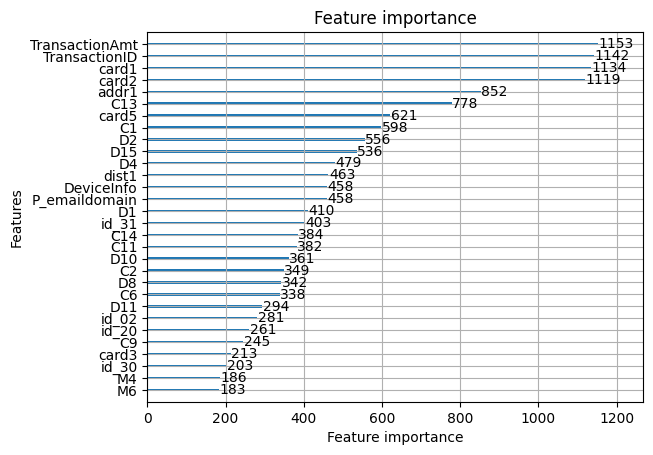

In [8]:
lgb.plot_importance(result_lgb, height=0.2, title='Feature importance', xlabel='Feature importance', ylabel='Features', importance_type='auto', grid=True, max_num_features=30, precision=3)

# XGB

In [9]:
train_data = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
test_data = xgb.DMatrix(X_test, label=y_test, enable_categorical=True)

In [10]:
xgb_params = {
    'max_leaves': 256,
    'min_child_weight': 79,
    'objective': 'binary:logistic',
    'max_depth': 13,
    'eta': 0.03,
    'tree_method': 'hist',
    'subsample': 0.9,
    'colsample_bytree': 0.9,
    'seed': 11,
    'eval_metric': 'auc',
    'verbosity': 0,
    'reg_alpha': 0.3,
    'reg_lambda': 0.3,
    'grow_policy': 'lossguide'  # needed so max_leaves is actually respected
}

result_xgb = xgb.train(
    xgb_params,
    train_data,
    num_boost_round=100,
    evals=[(train_data, 'train'), (test_data, 'valid')],
    verbose_eval=10
)

[0]	train-auc:0.86458	valid-auc:0.86695
[10]	train-auc:0.88448	valid-auc:0.88488
[20]	train-auc:0.89091	valid-auc:0.89016
[30]	train-auc:0.89746	valid-auc:0.89545
[40]	train-auc:0.90199	valid-auc:0.89871
[50]	train-auc:0.90583	valid-auc:0.90169
[60]	train-auc:0.90951	valid-auc:0.90489
[70]	train-auc:0.91268	valid-auc:0.90770
[80]	train-auc:0.91568	valid-auc:0.91043
[90]	train-auc:0.91854	valid-auc:0.91304
[99]	train-auc:0.92045	valid-auc:0.91485


In [11]:
y_pred_xgb = result_xgb.predict(test_data)

In [12]:
accuracy_xgb = accuracy_score(y_test, (y_pred_xgb > 0.5).astype(int))
roc_auc_xgb = roc_auc_score(y_test, y_pred_xgb)

print(f'Accuracy: {accuracy_xgb}')
print(f'ROC AUC: {roc_auc_xgb}')

Accuracy: 0.9745910522572561
ROC AUC: 0.9148517826519875


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

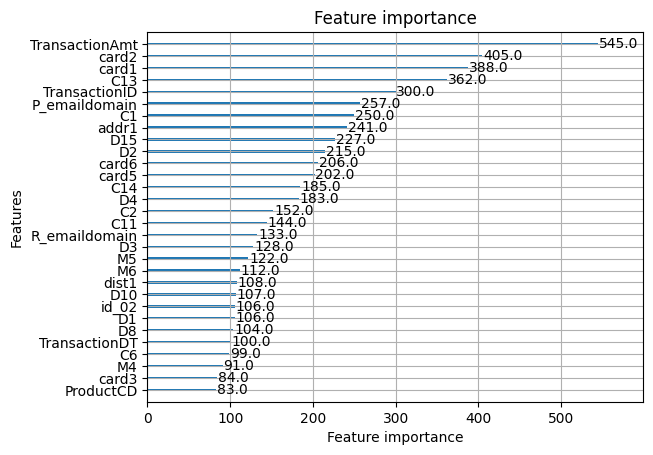

In [13]:
xgb.plot_importance(result_xgb, height=0.2, title='Feature importance', xlabel='Feature importance', ylabel='Features', max_num_features=30, grid=True)

# Compare Feature Importance

In [19]:
lgb_imp = pd.DataFrame({
    'feature': result_lgb.feature_name(),
    'lgb_gain': result_lgb.feature_importance(importance_type='gain'),
    'lgb_split': result_lgb.feature_importance(importance_type='split')
})

xgb_gain_dict = result_xgb.get_score(importance_type='gain')
xgb_weight_dict = result_xgb.get_score(importance_type='weight')  # weight ~= split count

all_features = X_train.columns.tolist()
xgb_imp = pd.DataFrame({
    'feature': all_features,
    'xgb_gain': [xgb_gain_dict.get(f, 0.0) for f in all_features],
    'xgb_split': [xgb_weight_dict.get(f, 0.0) for f in all_features]
})

In [20]:
imp = lgb_imp.merge(xgb_imp, on='feature', how='outer').fillna(0)

# Normalize gain within each model so they're on a comparable 0-1 scale
imp['lgb_gain_norm'] = imp['lgb_gain'] / imp['lgb_gain'].sum()
imp['xgb_gain_norm'] = imp['xgb_gain'] / imp['xgb_gain'].sum()

# Rank each model's features
imp['lgb_rank'] = imp['lgb_gain_norm'].rank(ascending=False, method='min')
imp['xgb_rank'] = imp['xgb_gain_norm'].rank(ascending=False, method='min')
imp['rank_diff'] = (imp['lgb_rank'] - imp['xgb_rank']).abs()

imp_sorted = imp.sort_values('lgb_gain_norm', ascending=False)
imp_sorted.head(30)

,feature,lgb_gain,lgb_split,xgb_gain,xgb_split,lgb_gain_norm,xgb_gain_norm,lgb_rank,xgb_rank,rank_diff
222,V258,236242.757592,49,3073.111572,41.0,0.181502,0.075819,1.0,3.0,2.0
0,C1,71769.478357,598,260.757355,250.0,0.055139,0.006433,2.0,22.0,20.0
5,C14,65697.212822,384,366.507263,185.0,0.050474,0.009042,3.0,15.0,12.0
262,V294,53485.747698,73,1020.809265,32.0,0.041092,0.025185,4.0,7.0,3.0
42,R_emaildomain,38874.040773,151,223.891235,133.0,0.029866,0.005524,5.0,27.0,22.0
29,DeviceInfo,37557.013197,458,72.906303,18.0,0.028854,0.001799,6.0,87.0,81.0
4,C13,34767.170037,778,74.008560,362.0,0.026711,0.001826,7.0,84.0,77.0
43,TransactionAmt,31264.676254,1153,38.726875,545.0,0.024020,0.000955,8.0,165.0,157.0
21,D2,31185.226754,556,124.835411,215.0,0.023959,0.003080,9.0,47.0,38.0
388,card2,29725.582976,1119,33.074261,405.0,0.022838,0.000816,10.0,190.0,180.0


In [21]:
corr, pval = spearmanr(imp['lgb_gain_norm'], imp['xgb_gain_norm'])
print(f'Spearman rank correlation between LGBM and XGBoost importances: {corr:.3f} (p={pval:.3g})')

# Features that swing the most between the two models' opinions of them
print("\nFeatures both models rank in their combined top 20 but disagree on:")
top_by_either = imp[(imp['lgb_rank'] <= 20) | (imp['xgb_rank'] <= 20)]
print(top_by_either.sort_values('rank_diff', ascending=False)[
    ['feature', 'lgb_rank', 'xgb_rank', 'rank_diff']
].head(15))

Spearman rank correlation between LGBM and XGBoost importances: 0.668 (p=2.81e-57)

Features both models rank in their combined top 20 but disagree on:
            feature  lgb_rank  xgb_rank  rank_diff
209            V246     356.0       4.0      352.0
207            V244     254.0       2.0      252.0
385           addr1      13.0     227.0      214.0
387           card1      12.0     225.0      213.0
391           card5      18.0     213.0      195.0
388           card2      10.0     190.0      180.0
240            V274     194.0      17.0      177.0
289            V318     175.0       6.0      169.0
45    TransactionID      11.0     172.0      161.0
40    P_emaildomain      16.0     175.0      159.0
43   TransactionAmt       8.0     165.0      157.0
231            V266     177.0      20.0      157.0
20              D15      17.0     152.0      135.0
375             V90     114.0       5.0      109.0
216            V252     111.0      18.0       93.0


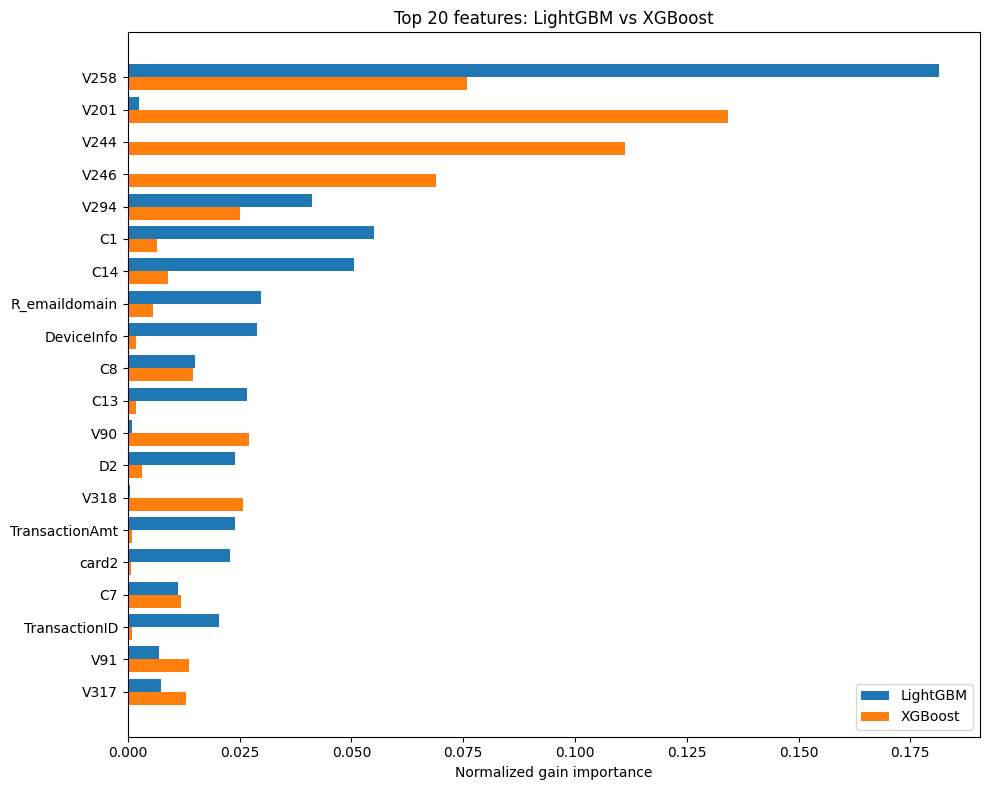

In [22]:
top_n = 20
imp['combined_score'] = imp['lgb_gain_norm'] + imp['xgb_gain_norm']
top_features = imp.sort_values('combined_score', ascending=False).head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(len(top_features))
width = 0.4

ax.barh(y_pos - width/2, top_features['lgb_gain_norm'], height=width, label='LightGBM')
ax.barh(y_pos + width/2, top_features['xgb_gain_norm'], height=width, label='XGBoost')
ax.set_yticks(y_pos)
ax.set_yticklabels(top_features['feature'])
ax.invert_yaxis()
ax.set_xlabel('Normalized gain importance')
ax.set_title(f'Top {top_n} features: LightGBM vs XGBoost')
ax.legend()
plt.tight_layout()
plt.show()

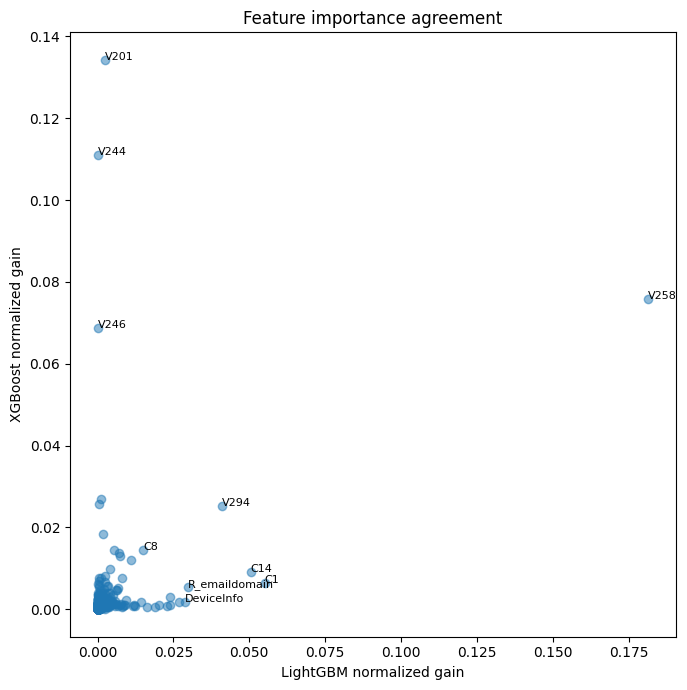

In [23]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(imp['lgb_gain_norm'], imp['xgb_gain_norm'], alpha=0.5)

# label the biggest outliers / most important points
for _, row in top_features.head(10).iterrows():
    ax.annotate(row['feature'], (row['lgb_gain_norm'], row['xgb_gain_norm']), fontsize=8)

ax.set_xlabel('LightGBM normalized gain')
ax.set_ylabel('XGBoost normalized gain')
ax.set_title('Feature importance agreement')
plt.tight_layout()
plt.show()

# Insights
- Top consensus features (high in both models): V258, C1, C14, V294, R_emaildomain, DeviceInfo, C13
	- Strong candidates
- Correlation of 0.668 between LGBM/XGB rankings
	- decent but not high agreement, single-model feature importance alone is risky for selection
- addr1, card1, card2, card5, TransactionAmt lean much more important in LGBM than XGBoost
- V244, V246, V318, V266, V90 lean much more important in XGBoost than LGBM
- TransactionID appears with notable importance in both models
	- unsure about whether or not we would want to include this since it may be  a leakage, not a real predictor
- Many V-columns cluster near the top for at least one model, may want to cross-reference those with the ones we cut during our reduction